<a href="https://colab.research.google.com/github/Suman-Nazir/Data-Analysis-Data-Science-Ai-ML-/blob/main/ML_Project_using_ML%26DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Path = 'drive/My Drive/ML'

In [ ]:
import pandas as pd
df = pd.read_csv (Path+'/Pakistani_Diabetes_Dataset.csv')
df.head()

,Age,Gender,Rgn,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
for name, acc in results.items():
    print(f"{name} Accuracy: {acc:.2%}")

KNN Accuracy: 98.36%
Decision Tree Accuracy: 99.45%
SVM Accuracy: 99.45%


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
ann = Sequential()
ann.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dropout(0.3))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=10, validation_split=0.2, callbacks=[early_stop])
train_loss, train_acc = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5729 - loss: 0.8238 - val_accuracy: 0.7055 - val_loss: 0.5498
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7366 - loss: 0.5107 - val_accuracy: 0.9315 - val_loss: 0.3650
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8933 - loss: 0.3624 - val_accuracy: 0.9521 - val_loss: 0.2549
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9615 - loss: 0.2358 - val_accuracy: 0.9658 - val_loss: 0.1937
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9462 - loss: 0.1863 - val_accuracy: 0.9726 - val_loss: 0.1640
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9724 - loss: 0.1265 - val_accuracy: 0.9726 - val_loss: 0.1490
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9819 - loss: 0.1224 - val_accuracy: 0.9726 - val_loss: 0.1403
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9729 - loss: 0.1070 - val_accuracy: 0.9658 - val_loss:

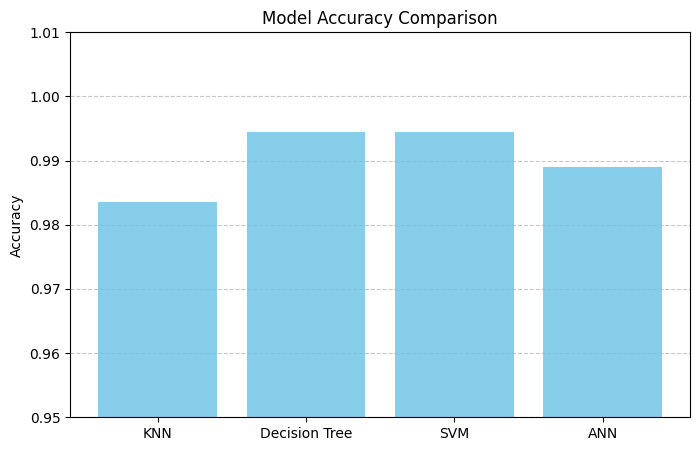

In [ ]:
import matplotlib.pyplot as plt
all_model_results = {
    "KNN": results["KNN"],
    "Decision Tree": results["Decision Tree"],
    "SVM": results["SVM"],
    "ANN": test_acc
}
plt.figure(figsize=(8, 5))
plt.bar(all_model_results.keys(), all_model_results.values(), color='skyblue')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.95, 1.01)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()